In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
bitcoin = pd.read_csv("BTC-EUR.csv", index_col = "Date", parse_dates = True)

<Axes: xlabel='Date'>

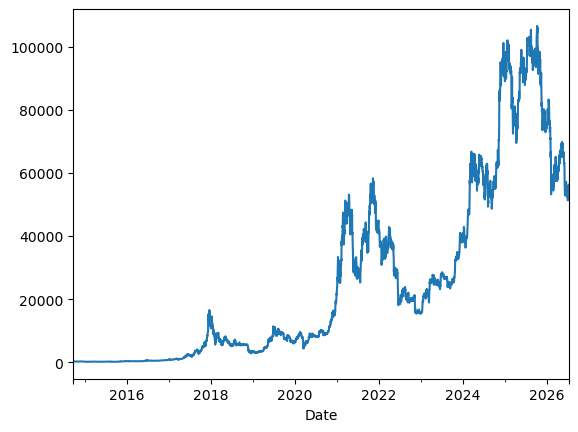

In [8]:
bitcoin["Close"].plot()

In [21]:
data = bitcoin.copy()

In [23]:
data["buy"] = np.zeros(len(data))
data["sell"] = np.zeros(len(data))

In [25]:
data["rolling_max"] = data["Close"].shift(1).rolling(window = 28).max()
data["rolling_min"] = data["Close"].shift(1).rolling(window = 28).min()
data.loc[data["rolling_max"]<data["Close"], "buy"] = 1
data.loc[data["rolling_min"]<data["Close"], "sell"] = -1

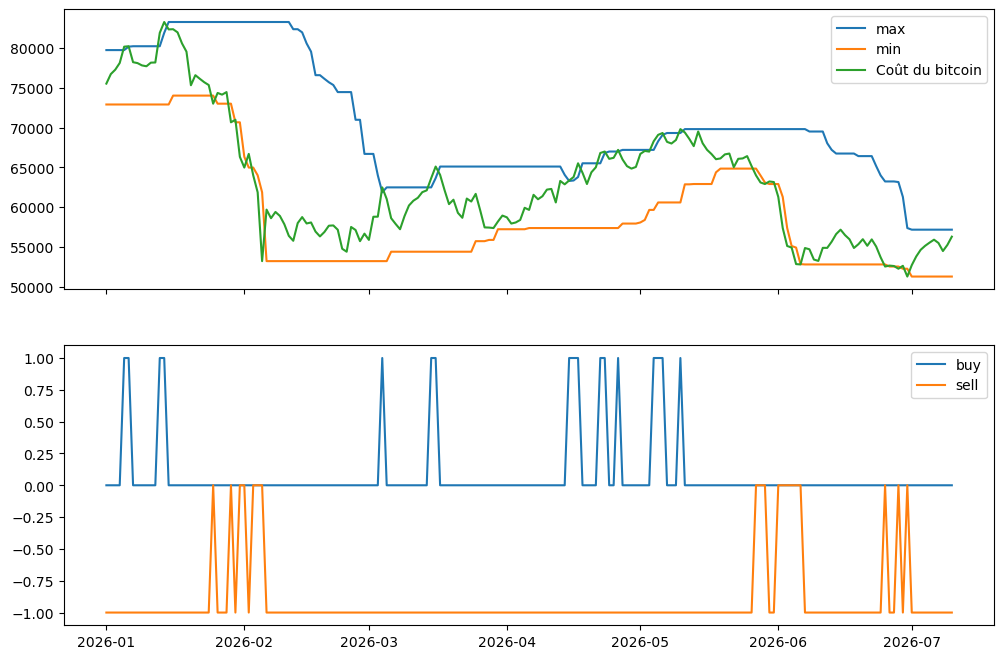

In [33]:
start = "2026"
end = "2026"
fig, ax = plt.subplots(2, figsize = (12,8), sharex = True)
ax[0].plot(data["rolling_max"][start:end])
ax[0].plot(data["rolling_min"][start:end])
ax[0].plot(data["Close"][start:end])
ax[0].legend(["max", "min", "Coût du bitcoin"])
ax[1].plot(data["buy"][start:end])
ax[1].plot(data["sell"][start : end])
ax[1].legend(["buy", "sell"])
plt.show()